In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [2]:
data = pd.read_csv('fuel_raw_data.csv')

In [3]:
data.head ()

,Date,Country,Region,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation_Rate (%),Exchange_Rate_vs_USD,GDP_Growth (%),...,Geopolitical_Risk_Index,Event_Flag,Event_Description,Currency_Devaluation (%),Subsidy_Level,Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1
0,2015-01-05,Brazil,Latin America,0.675,0.609,1.769,50.91,2.42,5.1316,0.58,...,20.4,0,NaN,0.32,Medium,20.0,0.675000,NaN,NaN,NaN
1,2015-01-12,Brazil,Latin America,0.687,0.602,1.565,51.57,3.39,5.2201,2.08,...,23.5,0,NaN,-0.41,Medium,20.0,0.681000,NaN,0.675,50.91
2,2015-01-19,Brazil,Latin America,0.710,0.642,1.760,53.96,2.03,5.0857,3.43,...,21.1,0,NaN,0.35,Medium,20.0,0.690667,0.011102,0.687,51.57
3,2015-01-26,Brazil,Latin America,0.802,0.713,1.500,58.69,2.30,5.2486,1.96,...,24.5,0,NaN,-0.46,Medium,20.0,0.718500,0.060526,0.710,53.96
4,2015-02-02,Brazil,Latin America,0.685,0.650,1.500,52.61,1.96,5.2284,1.83,...,25.4,0,NaN,-0.74,Medium,20.0,0.721000,0.114316,0.802,58.69


In [4]:
# Set pandas options to display all columns and rows clearly
pd.set_option('display.max_columns', None)

In [5]:
data.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860 entries, 0 to 5859
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             5860 non-null   object 
 1   Country                          5860 non-null   object 
 2   Region                           5860 non-null   object 
 3   Petrol_Price_USD_per_Liter       5860 non-null   float64
 4   Diesel_Price_USD_per_Liter       5860 non-null   float64
 5   Natural_Gas_Price_USD_per_MMBtu  5860 non-null   float64
 6   Crude_Oil_Price_USD_per_Barrel   5860 non-null   float64
 7   Inflation_Rate (%)               5860 non-null   float64
 8   Exchange_Rate_vs_USD             5860 non-null   float64
 9   GDP_Growth (%)                   5860 non-null   float64
 10  Supply_Index                     5860 non-null   float64
 11  Demand_Index                     5860 non-null   float64
 12  Geopolitical_Risk_In

In [6]:
data.describe ()

,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation_Rate (%),Exchange_Rate_vs_USD,GDP_Growth (%),Supply_Index,Demand_Index,Geopolitical_Risk_Index,Event_Flag,Currency_Devaluation (%),Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1
count,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5840.000000,5850.000000,5850.000000
mean,0.838600,0.752848,1.776439,57.443406,3.096753,41.957688,1.997531,50.200444,50.131365,28.570802,0.166724,0.002493,25.600000,0.837801,0.067361,0.838253,57.419603
std,0.199531,0.175306,0.300398,9.904936,1.684595,80.398213,1.484169,8.589973,8.933544,9.133853,0.372761,0.498575,12.052584,0.194522,0.019811,0.199433,9.896569
min,0.381000,0.363000,1.500000,35.590000,0.240000,0.726000,-3.180000,20.400000,19.200000,20.000000,0.000000,-1.680000,10.000000,0.428250,0.002337,0.381000,35.590000
25%,0.690000,0.622750,1.500000,49.710000,2.180000,0.987775,1.000000,44.400000,44.175000,23.000000,0.000000,-0.340000,18.000000,0.692750,0.053716,0.690000,49.710000
50%,0.814000,0.731000,1.687000,56.745000,2.620000,6.438800,1.990000,50.100000,50.100000,26.100000,0.000000,0.000000,22.500000,0.816000,0.065127,0.813000,56.710000
75%,0.965000,0.863000,1.958000,63.760000,3.220000,74.064575,3.000000,56.000000,56.100000,29.000000,0.000000,0.330000,38.000000,0.960500,0.077718,0.964750,63.710000
max,1.601000,1.424000,3.140000,91.850000,11.410000,532.271200,7.870000,79.500000,82.600000,69.500000,1.000000,1.760000,45.000000,1.533500,0.145735,1.601000,91.850000


In [7]:
data.sample (10)

,Date,Country,Region,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation_Rate (%),Exchange_Rate_vs_USD,GDP_Growth (%),Supply_Index,Demand_Index,Geopolitical_Risk_Index,Event_Flag,Event_Description,Currency_Devaluation (%),Subsidy_Level,Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1
3342,2022-11-28,Japan,Asia,0.783,0.720,1.693,50.20,3.22,108.4884,2.02,54.9,60.5,25.6,0,NaN,0.03,Low,30.0,0.80225,0.054621,0.794,50.88
2075,2021-02-01,Germany,Europe,1.101,1.011,1.799,62.01,3.34,0.8693,4.41,45.8,54.7,29.7,0,NaN,0.27,Low,45.0,1.10725,0.050329,1.111,62.16
2436,2016-10-10,India,Asia,0.459,0.407,1.500,39.77,3.23,73.5083,3.18,45.6,56.0,26.5,0,NaN,0.30,High,10.0,0.50700,0.068153,0.548,44.89
3097,2018-03-19,Japan,Asia,1.055,0.971,1.672,68.62,2.68,111.7485,2.37,54.1,46.6,20.1,0,NaN,0.90,Low,30.0,1.03550,0.071904,1.041,65.25
721,2017-08-07,China,Asia,0.703,0.635,1.728,49.53,2.14,6.4747,3.74,44.7,47.9,28.2,0,NaN,0.21,Medium,25.0,0.68050,0.080405,0.657,46.30
5427,2017-12-11,United States,North America,0.698,0.648,1.500,49.99,2.51,0.9932,2.37,59.3,46.7,28.7,0,NaN,-0.43,Low,18.0,0.67575,0.082980,0.646,46.01
5520,2019-09-23,United States,North America,0.638,0.579,1.500,45.80,2.40,0.9760,1.65,51.5,47.1,20.5,0,NaN,0.21,Low,18.0,0.65025,0.108652,0.632,44.70
596,2015-03-16,China,Asia,0.861,0.774,1.966,59.49,2.24,6.6091,2.57,44.0,45.3,25.3,0,NaN,-0.36,Medium,25.0,0.84800,0.037366,0.845,58.95
2642,2020-09-21,India,Asia,0.560,0.508,1.706,47.60,1.86,72.3745,3.98,37.4,42.7,22.4,0,NaN,0.19,High,10.0,0.56425,0.040565,0.574,47.15
2691,2021-08-30,India,Asia,0.540,0.510,1.627,46.60,2.84,72.9516,2.57,52.9,63.0,26.7,0,NaN,-0.76,High,10.0,0.56250,0.043208,0.548,45.39


In [8]:
data.isnull ().sum ()

,0
Date,0
Country,0
Region,0
Petrol_Price_USD_per_Liter,0
Diesel_Price_USD_per_Liter,0
Natural_Gas_Price_USD_per_MMBtu,0
Crude_Oil_Price_USD_per_Barrel,0
Inflation_Rate (%),0
Exchange_Rate_vs_USD,0
GDP_Growth (%),0


In [9]:
data['Date'] = pd.to_datetime(data['Date'])

In [10]:
data.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860 entries, 0 to 5859
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             5860 non-null   datetime64[ns]
 1   Country                          5860 non-null   object        
 2   Region                           5860 non-null   object        
 3   Petrol_Price_USD_per_Liter       5860 non-null   float64       
 4   Diesel_Price_USD_per_Liter       5860 non-null   float64       
 5   Natural_Gas_Price_USD_per_MMBtu  5860 non-null   float64       
 6   Crude_Oil_Price_USD_per_Barrel   5860 non-null   float64       
 7   Inflation_Rate (%)               5860 non-null   float64       
 8   Exchange_Rate_vs_USD             5860 non-null   float64       
 9   GDP_Growth (%)                   5860 non-null   float64       
 10  Supply_Index                     5860 non-null   float64    

In [11]:
data = data.sort_values(by=['Country', 'Date']).reset_index(drop=True)

In [12]:
# Filling missing values

# fill the null in Event_Description with 'No Event'
data['Event_Description'] = data['Event_Description'].fillna('No Event')

# Petrol 28-day volatility
data['Petrol_28d_vol'] = data.groupby('Country')['Petrol_28d_vol'].ffill()
data['Petrol_28d_vol'] = data.groupby('Country')['Petrol_28d_vol'].bfill()

# Petrol_lag_1
data['Petrol_lag_1'] = data.groupby('Country')['Petrol_lag_1'].ffill()
data['Petrol_lag_1'] = data.groupby('Country')['Petrol_lag_1'].bfill()

# Crude_lag_1
data['Crude_lag_1'] = data.groupby('Country')['Crude_lag_1'].ffill()
data['Crude_lag_1'] = data.groupby('Country')['Crude_lag_1'].bfill()


In [13]:
data.isnull().sum()

,0
Date,0
Country,0
Region,0
Petrol_Price_USD_per_Liter,0
Diesel_Price_USD_per_Liter,0
Natural_Gas_Price_USD_per_MMBtu,0
Crude_Oil_Price_USD_per_Barrel,0
Inflation_Rate (%),0
Exchange_Rate_vs_USD,0
GDP_Growth (%),0


In [14]:
# Creating Scarcity Likelihood Flag column

data['Scarcity_Flag'] = ((data['Demand_Index'] > data['Supply_Index']) & (data['Supply_Index'] < 40)).astype(int)


In [15]:
data[data['Scarcity_Flag']==True]

,Date,Country,Region,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation_Rate (%),Exchange_Rate_vs_USD,GDP_Growth (%),Supply_Index,Demand_Index,Geopolitical_Risk_Index,Event_Flag,Event_Description,Currency_Devaluation (%),Subsidy_Level,Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1,Scarcity_Flag
1,2015-01-12,Brazil,Latin America,0.687,0.602,1.565,51.57,3.39,5.2201,2.08,39.9,67.4,23.5,0,No Event,-0.41,Medium,20.0,0.68100,0.011102,0.675,50.91,1
11,2015-03-23,Brazil,Latin America,0.768,0.707,1.853,59.56,2.02,5.2418,2.52,38.8,55.3,22.7,0,No Event,0.58,Medium,20.0,0.79075,0.076017,0.792,59.27,1
12,2015-03-30,Brazil,Latin America,0.792,0.701,1.774,59.89,2.33,5.2205,0.19,35.0,39.8,24.5,0,No Event,0.22,Medium,20.0,0.79150,0.072640,0.768,59.56,1
35,2015-09-07,Brazil,Latin America,0.530,0.464,1.500,39.52,2.45,5.1947,1.91,38.8,55.2,27.2,0,No Event,0.45,Medium,20.0,0.57975,0.054298,0.596,45.17,1
40,2015-10-12,Brazil,Latin America,0.560,0.498,1.500,42.22,2.34,5.1446,2.27,36.3,37.4,29.4,0,No Event,0.42,Medium,20.0,0.52600,0.071510,0.555,40.47,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5833,2025-09-22,United States,North America,0.721,0.635,1.769,50.25,4.30,4.5144,2.00,38.5,58.2,25.8,0,No Event,-0.33,Low,18.0,0.72150,0.042393,0.688,50.03,1
5837,2025-10-20,United States,North America,0.739,0.643,1.699,51.01,2.83,4.4892,1.80,37.0,68.2,26.3,0,No Event,-0.49,Low,18.0,0.76250,0.047064,0.792,54.79,1
5838,2025-10-27,United States,North America,0.766,0.706,1.757,54.95,2.11,4.4521,4.20,39.5,42.8,25.4,0,No Event,-0.06,Low,18.0,0.76700,0.046623,0.739,51.01,1
5841,2025-11-17,United States,North America,0.728,0.662,1.618,52.76,3.80,4.5305,4.18,37.0,47.1,28.8,0,No Event,0.97,Low,18.0,0.74125,0.042782,0.724,50.86,1


### Exploratory Data Analysis (EDA): Fuel Price Distributions

In [16]:
# Extract Time-Based Features
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Quarter'] = data['Date'].dt.quarter
data['Week'] = data['Date'].dt.isocalendar().week.astype(int)
data['Day_Of_Week'] = data['Date'].dt.dayofweek

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860 entries, 0 to 5859
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             5860 non-null   datetime64[ns]
 1   Country                          5860 non-null   object        
 2   Region                           5860 non-null   object        
 3   Petrol_Price_USD_per_Liter       5860 non-null   float64       
 4   Diesel_Price_USD_per_Liter       5860 non-null   float64       
 5   Natural_Gas_Price_USD_per_MMBtu  5860 non-null   float64       
 6   Crude_Oil_Price_USD_per_Barrel   5860 non-null   float64       
 7   Inflation_Rate (%)               5860 non-null   float64       
 8   Exchange_Rate_vs_USD             5860 non-null   float64       
 9   GDP_Growth (%)                   5860 non-null   float64       
 10  Supply_Index                     5860 non-null   float64    

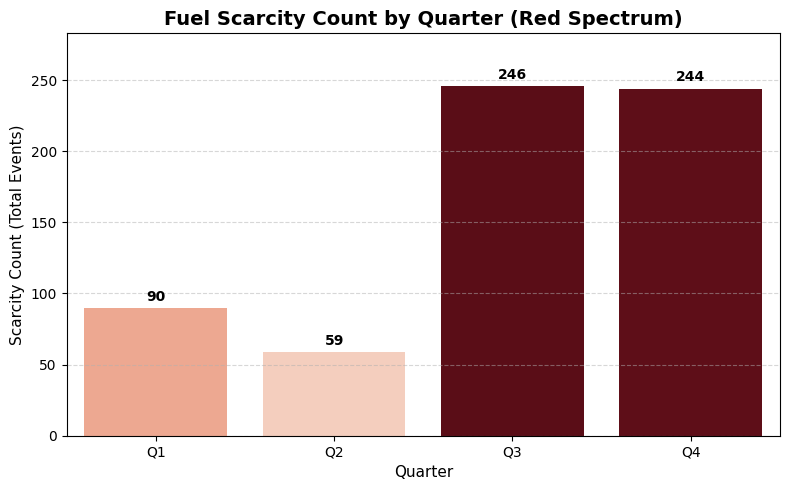

In [18]:
import matplotlib.colors as mcolors

# Aggregate Scarcity Count by Quarter
quarterly_scarcity = data.groupby('Quarter')['Scarcity_Flag'].agg(
    Scarcity_Count='sum'
).reset_index()

# Map Quarter numbers to Q1 - Q4
quarterly_scarcity['Quarter_Name'] = quarterly_scarcity['Quarter'].apply(lambda x: f'Q{x}')

# Create a Red Gradient Spectrum based on Scarcity_Count
min_val = quarterly_scarcity['Scarcity_Count'].min()
max_val = quarterly_scarcity['Scarcity_Count'].max()

# Normalize values between 0.2 (light) and 1.0 (bright) so light red remains easily visible
norm_values = [0.2 + 0.8 * (val - min_val) / (max_val - min_val) for val in quarterly_scarcity['Scarcity_Count']]

# Generate custom red colors from light pinkish-red to bright crimson
cmap = plt.cm.Reds
spectrum_palette = [mcolors.to_hex(cmap(val)) for val in norm_values]

# Plot Scarcity Count per Quarter
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x='Quarter_Name',
    y='Scarcity_Count',
    hue='Quarter_Name',
    data=quarterly_scarcity,
    palette=spectrum_palette,
    legend=False
)

# Annotate exact count value above each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', xytext=(0, 3),
            textcoords='offset points', fontsize=10, fontweight='bold'
        )

plt.title('Fuel Scarcity Count by Quarter (Red Spectrum)', fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontsize=11)
plt.ylabel('Scarcity Count (Total Events)', fontsize=11)
plt.ylim(0, max_val * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

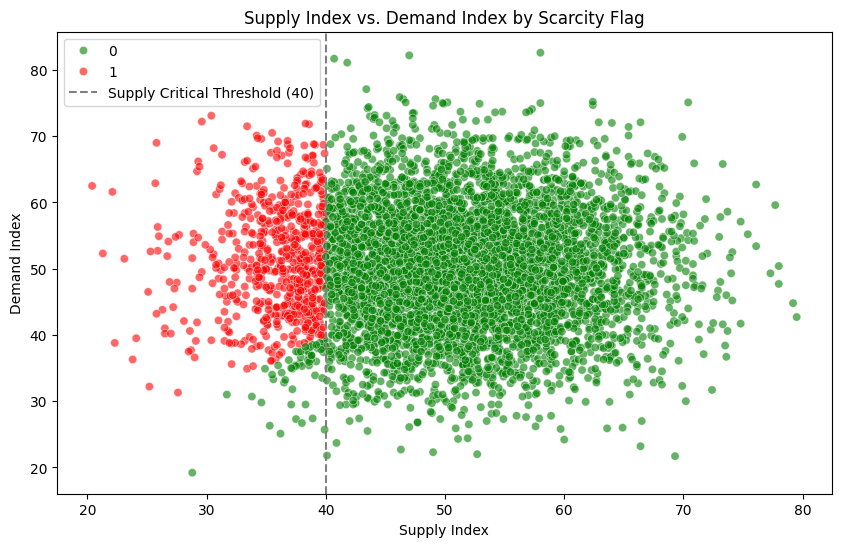

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Supply_Index',
    y='Demand_Index',
    hue='Scarcity_Flag',
    data=data,
    alpha=0.6,
    palette=['g', 'r']
)
plt.axvline(40, color='gray', linestyle='--', label='Supply Critical Threshold (40)')
plt.title('Supply Index vs. Demand Index by Scarcity Flag')
plt.xlabel('Supply Index')
plt.ylabel('Demand Index')
plt.legend()
plt.show()

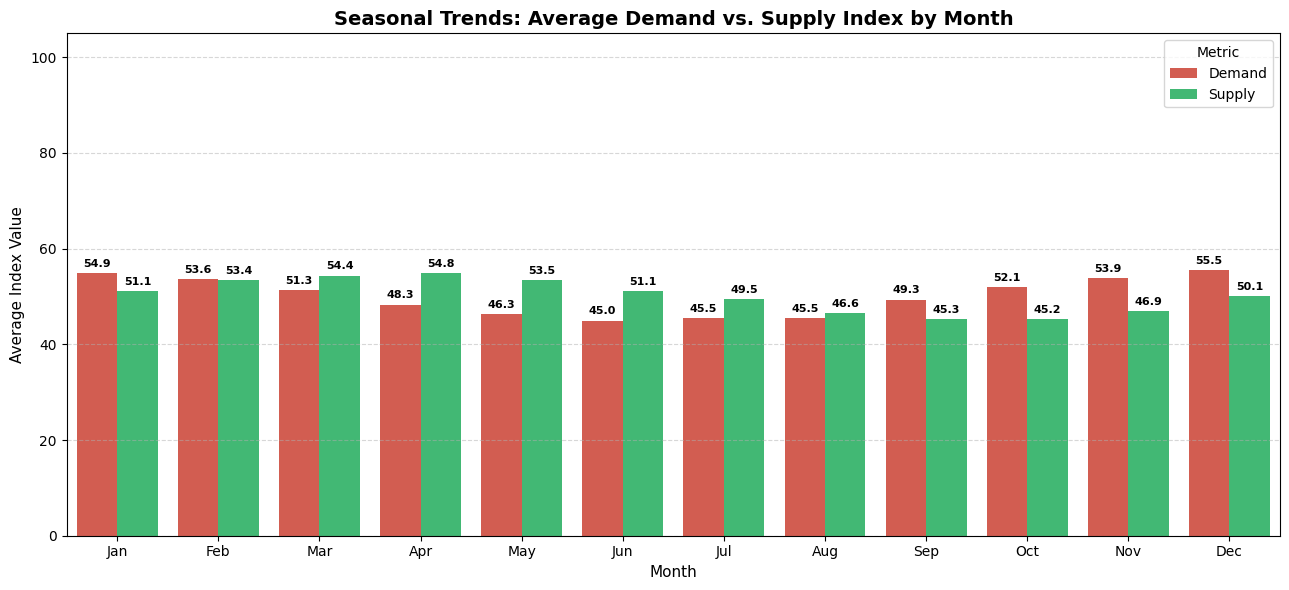

In [20]:
# Aggregate average Demand and Supply by Month
monthly_trends = data.groupby('Month')[['Demand_Index', 'Supply_Index']].mean().reset_index()

# Convert Month numbers (1-12) to Month Names ('Jan'-'Dec')
monthly_trends['Month_Name'] = monthly_trends['Month'].apply(lambda x: calendar.month_abbr[x])

# Reshape (melt) the DataFrame for Seaborn
monthly_melted = monthly_trends.melt(
    id_vars=['Month_Name'],
    value_vars=['Demand_Index', 'Supply_Index'],
    var_name='Metric',
    value_name='Average Index'
)
monthly_melted['Metric'] = monthly_melted['Metric'].map({'Demand_Index': 'Demand', 'Supply_Index': 'Supply'})

# Plot the Grouped Bar Chart
plt.figure(figsize=(13, 6))
ax = sns.barplot(
    x='Month_Name',
    y='Average Index',
    hue='Metric',
    data=monthly_melted,
    palette=['#e74c3c', '#2ecc71']
)

# Annotate exact value above each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', xytext=(0, 3),
            textcoords='offset points', fontsize=8, fontweight='bold'
        )

plt.title('Seasonal Trends: Average Demand vs. Supply Index by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Average Index Value', fontsize=11)
plt.ylim(0, 105)  # Headroom for value annotations
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

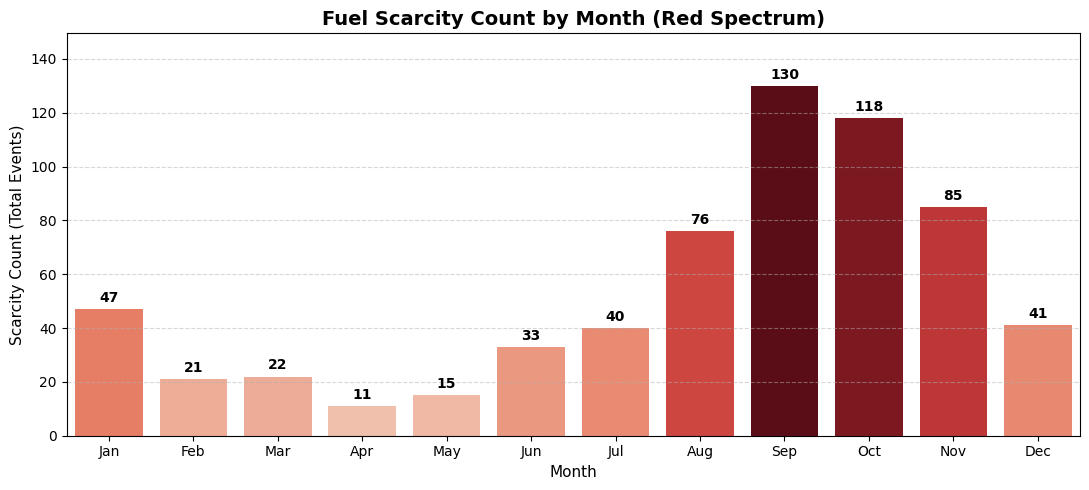

In [21]:
# Aggregate Scarcity Count by Month
monthly_scarcity = data.groupby('Month')['Scarcity_Flag'].agg(
    Scarcity_Count='sum'
).reset_index()

# Map month number to abbreviated name
monthly_scarcity['Month_Name'] = monthly_scarcity['Month'].apply(lambda x: calendar.month_abbr[x])

# Create Red Gradient Spectrum
min_val = monthly_scarcity['Scarcity_Count'].min()
max_val = monthly_scarcity['Scarcity_Count'].max()

# Normalize values between 0.25 (light red) and 1.0 (bright red)
norm_values = [0.25 + 0.75 * (val - min_val) / (max_val - min_val) for val in monthly_scarcity['Scarcity_Count']]
cmap = plt.cm.Reds
spectrum_palette = [mcolors.to_hex(cmap(val)) for val in norm_values]

# Plot
plt.figure(figsize=(11, 5))
ax = sns.barplot(
    x='Month_Name',
    y='Scarcity_Count',
    hue='Month_Name',
    data=monthly_scarcity,
    palette=spectrum_palette,
    legend=False
)

# Annotate exact count value above each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', xytext=(0, 3),
            textcoords='offset points', fontsize=10, fontweight='bold'
        )

plt.title('Fuel Scarcity Count by Month (Red Spectrum)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Scarcity Count (Total Events)', fontsize=11)
plt.ylim(0, max_val * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

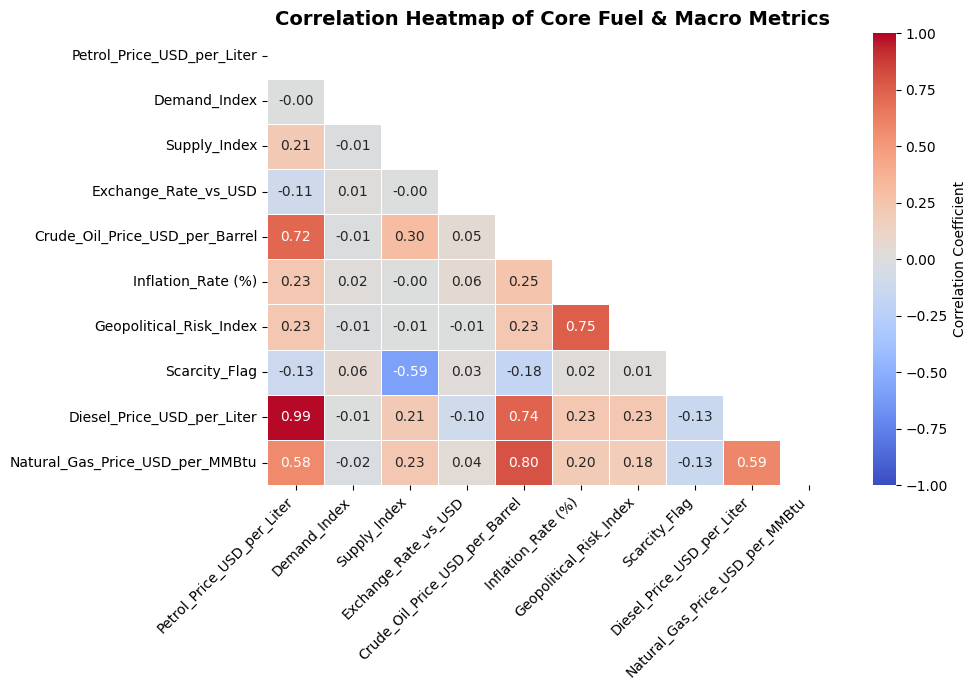

In [22]:
# Select core numerical features
core_cols = [
    'Petrol_Price_USD_per_Liter',
    'Demand_Index',
    'Supply_Index',
    'Exchange_Rate_vs_USD',
    'Crude_Oil_Price_USD_per_Barrel',
    'Inflation_Rate (%)',
    'Geopolitical_Risk_Index',
    'Scarcity_Flag',
    'Diesel_Price_USD_per_Liter',
    'Natural_Gas_Price_USD_per_MMBtu'
]

# Calculate correlation matrix
corr_matrix = data[core_cols].corr()

# Create a mask to hide the upper triangle (above the diagonal)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot lower triangle heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    mask=mask,          # Hides the upper diagonal duplicate values
    annot=True,
    fmt=".2f",          # Rounds correlation values to 2 decimal places
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Core Fuel & Macro Metrics', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
# Save the cleaned dataset to a CSV file
data.to_csv('fuel_processed_data.csv', index=False)

print("Processed dataset saved successfully as 'fuel_processed_data.csv'!")

Processed dataset saved successfully as 'fuel_processed_data.csv'!
